# CREDIT RISK DATASET

## 1. Importar librerías y *Credit Risk Dataset*

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

# Preprocesamiento y partición de datos
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Pipeline, preprocesamiento y búsqueda de hiperparámetros
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    make_scorer,
)

# Visualización LaTeX en notebook
from IPython.display import display, Math

In [2]:
df = pd.read_csv(r"C:\Users\usuario\OneDrive\Proyectos\TFG\credit_risk_dataset.csv")

## 2. Análisis exploratorio

In [111]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [112]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [114]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [115]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [116]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [117]:
# Eliminar registros con person_age > 90 y person_emp_length == 123
print(f"Registros antes: {len(df)}")
df = df[df['person_age'] <= 90]
df = df[df['person_emp_length'] != 123]
print(f"Registros después: {len(df)}")

Registros antes: 32581
Registros después: 32573


## 3. Modelos de clasificación

Se entrenan tres modelos de clasificación (**Regresión Logística**, **K-NN** y **Árbol de Clasificación**) siguiendo el siguiente esquema:

- **División train/test**: 80 % / 20 %, estratificada por `loan_status` y `random_state=42`.
- **Validación cruzada**: 5 *folds* estratificados sobre el conjunto de entrenamiento.
- **Métrica de selección**: AUC.
- **Preprocesamiento**:
  - Imputación de valores faltantes en `person_emp_length` y `loan_int_rate` con `KNNImputer` (k=5).
  - `StandardScaler` sobre las variables cuantitativas para la regresión logística y el K-NN. Para la regresión logística no sería estrictamente necesario, no obstante las escalaremos con el objetivo de facilitar la interpretación de los *odds ratios*.
  - `OneHotEncoder` con `drop='first'` para la Regresión Logística (categoría de referencia) y `drop=None` para K-NN y Árbol (todas las dummies).

Para cada modelo se reportan, con la mejor combinación de hiperparámetros, las medias en CV de AUC, exactitud, tasa de error, precisión, sensibilidad, especificidad y F1-Score, y se reentrena el estimador ganador sobre todo el conjunto de entrenamiento.

### 3.1. División train/test

In [118]:
# Separar features y target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# División train/test (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean()*100:.2f}% default)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean()*100:.2f}% default)")

Train: 26058 registros (21.82% default)
Test:  6515 registros (21.81% default)


### 3.2. Pipelines de preprocesamiento

Se definen **tres** `ColumnTransformer`, uno por modelo, para aplicar el preprocesado más adecuado a cada algoritmo:

| Preprocessor | Imputación | Escalado | OneHot `drop` | Usado por |
|---|---|---|---|---|
| `preprocessor_lr` | KNNImputer(k=5) | **StandardScaler** | `'first'` | Regresión Logística |
| `preprocessor_knn` | KNNImputer(k=5) | **StandardScaler** | `None` | K-NN |
| `preprocessor_dt` | KNNImputer(k=5) | — | `None` | Árbol de Clasificación |

In [119]:
# Columnas numéricas y categóricas
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'cb_person_default_on_file']

# Pipelines numéricos
num_pipeline_scaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
num_pipeline_unscaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5))
])

# Pipelines categóricos 
cat_pipeline_lr = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_knn = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_dt = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformers por modelo
preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_lr, cat_cols)
])
preprocessor_knn = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_knn, cat_cols)
])
preprocessor_dt = ColumnTransformer([
    ('num', num_pipeline_unscaled, num_cols),
    ('cat', cat_pipeline_dt, cat_cols)
])

### 3.3. Esquema de validación cruzada y métricas

In [120]:
# Especificidad 
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Tasa de error
def error_rate_score(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

# Diccionario de métricas
scoring = {
    'AUC':           'roc_auc',
    'Exactitud':     'accuracy',
    'Tasa de error': make_scorer(error_rate_score),
    'Precisión':     'precision',
    'Sensibilidad':  'recall',
    'Especificidad': make_scorer(specificity_score),
    'F1-Score':      'f1'
}

# Estrategia de CV: 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 3.4. Regresión Logística

Se entrena una regresión logística **sin penalización** (`C=np.inf`). No hay hiperparámetros que ajustar por validación cruzada: simplemente se estiman los coeficientes con el solver 'lbfgs' y se reportan las métricas medias en 5-fold CV.

In [121]:
# Regresión Logística 
lr_pipe = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(C=np.inf, max_iter=2000, random_state=42))
])

# Hiperparámetros fijos 
lr_best_params = {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

# Validación cruzada (5 folds) con todas las métricas
lr_cv = cross_validate(lr_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
lr_metrics = {m: lr_cv[f'test_{m}'].mean() for m in scoring}

print("=== Regresión Logística ===")
print(f"Hiperparámetros: {lr_best_params}")
print("\nMétricas medias (5-fold CV):")
for m, v in lr_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Reentrenar sobre todo el conjunto de entrenamiento
lr_pipe.fit(X_train, y_train)
print("\n→ Modelo reentrenado sobre todo X_train.")

# Guardar hiperparámetros en JSON
with open('lr_best_params.json', 'w') as f:
    json.dump(lr_best_params, f, indent=4)
print("→ Hiperparámetros guardados en lr_best_params.json")

=== Regresión Logística ===
Hiperparámetros: {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

Métricas medias (5-fold CV):
  AUC           : 0.8711
  Exactitud     : 0.8666
  Tasa de error : 0.1334
  Precisión     : 0.7649
  Sensibilidad  : 0.5612
  Especificidad : 0.9518
  F1-Score      : 0.6474

→ Modelo reentrenado sobre todo X_train.
→ Hiperparámetros guardados en lr_best_params.json


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [122]:
# Definición lr_model, coefs e intercept para Odds Ratios
lr_prep = lr_pipe.named_steps['preprocessor']
ohe_lr  = lr_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names_lr = list(ohe_lr.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_feature_names_lr

lr_model  = lr_pipe.named_steps['classifier']
coefs     = lr_model.coef_[0]
intercept = lr_model.intercept_[0]

In [123]:
# Tabla de los Odds Ratios
or_df = pd.DataFrame({
    'Variable':         feature_names,
    'Coeficiente (b)':  np.round(coefs, 4),
    'Odds Ratio (e^b)': np.round(np.exp(coefs), 4)
}).sort_values('Odds Ratio (e^b)', ascending=False).reset_index(drop=True)
or_df.index += 1

print(f'Intercepto (b₀): {intercept:.4f}\n')
or_df

Intercepto (b₀): -2.2694



,Variable,Coeficiente (b),Odds Ratio (e^b)
1,loan_grade_G,6.3114,550.8068
2,loan_grade_F,3.1679,23.7571
3,loan_grade_E,2.7244,15.2467
4,loan_grade_D,2.5062,12.2578
5,loan_percent_income,1.4755,4.3734
6,person_home_ownership_RENT,0.8373,2.3101
7,loan_grade_C,0.4087,1.5048
8,person_home_ownership_OTHER,0.2750,1.3165
9,loan_int_rate,0.2110,1.2350
10,loan_grade_B,0.1990,1.2202


### 3.5. K-NN

Búsqueda de la mejor combinación de hiperparámetros entre las 40 posibles:
- `n_neighbors` ∈ {1,  3,  5,  7,  9, 11, 13, 15, 17, 19,
        21, 23, 25, 27, 29, 31, 33, 35, 37, 39,
        41, 43, 45, 47, 49, 51, 55, 59, 63, 67,
        71, 75, 79, 83, 87, 91, 95,101,111,121,
       131,141,151,161,171,181,201,251,301,401}
- `weights` ∈ {'uniform', 'distance'}
- `metric` ∈ {'euclidean', 'manhattan'}

In [ ]:
# K-NN
knn_pipe = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier())
])

# Se prueba con 200 combinaciones de hiperparámetros (50 × 2 × 2)
knn_params = {
    'classifier__n_neighbors': [
         1,  3,  5,  7,  9, 11, 13, 15, 17, 19,
        21, 23, 25, 27, 29, 31, 33, 35, 37, 39,
        41, 43, 45, 47, 49, 51, 55, 59, 63, 67,
        71, 75, 79, 83, 87, 91, 95,101,111,121,
       131,141,151,161,171,181,201,251,301,401
    ],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipe, knn_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=1
)
knn_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
knn_best_idx = knn_grid.best_index_
knn_best_params = {k.replace('classifier__', ''): v for k, v in knn_grid.best_params_.items()}
knn_metrics = {m: knn_grid.cv_results_[f'mean_test_{m}'][knn_best_idx] for m in scoring}

print("=== K-NN ===")
print(f"Mejores hiperparámetros: {knn_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in knn_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON
with open('knn_best_params.json', 'w') as f:
    json.dump(knn_best_params, f, indent=4)
print("→ Hiperparámetros guardados en knn_best_params.json")

#### Curva AUC frente a $k$

Fijada la mejor combinación de hiperparámetros (`weights='distance'`, `metric='manhattan'`), se representa el AUC medio en validación cruzada en función del número de vecinos $k$. Esta curva permite visualizar empíricamente el **dilema sesgo-varianza** discutido en la Sección 2.4: valores muy pequeños de $k$ generan modelos de alta varianza (sobreajustan al ruido del *train*), mientras que valores muy grandes incrementan el sesgo (suavizan en exceso la frontera de decisión). El óptimo se sitúa en el valor de $k$ que minimiza el error en CV.

Curva AUC vs k  (weights='distance', metric='manhattan')

  k  mean_test_AUC  std_test_AUC
  1         0.7808        0.0037
  3         0.8540        0.0037
  5         0.8723        0.0033
  7         0.8825        0.0029
  9         0.8862        0.0030
 11         0.8891        0.0030
 13         0.8915        0.0021
 15         0.8930        0.0027
 17         0.8949        0.0028
 19         0.8968        0.0028
 21         0.8976        0.0026
 23         0.8985        0.0026
 25         0.8984        0.0026
 27         0.8984        0.0030
 29         0.8991        0.0027
 31         0.8997        0.0029
 33         0.9001        0.0031
 35         0.9002        0.0028
 37         0.9003        0.0028
 39         0.9002        0.0028
 41         0.8996        0.0027
 43         0.8993        0.0025
 45         0.8995        0.0025
 47         0.8996        0.0026
 49         0.8997        0.0026
 51         0.8995        0.0026
 55         0.8995        0.0025
 59         0.8998

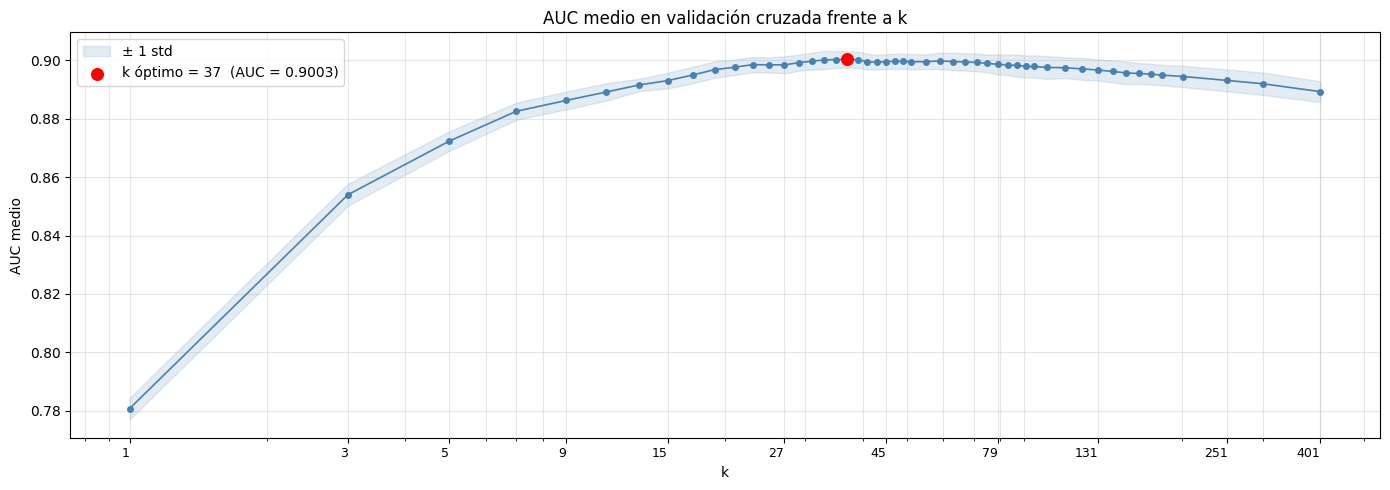

: 

In [ ]:
# Curva AUC vs k con la mejor combinación de weights y metric
best_w = knn_best_params['weights']
best_m = knn_best_params['metric']

knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
mask = (
    (knn_cv_df['param_classifier__weights'] == best_w) &
    (knn_cv_df['param_classifier__metric']  == best_m)
)
curve_df = (
    knn_cv_df.loc[mask]
        .assign(k=lambda d: d['param_classifier__n_neighbors'].astype(int))
        [['k', 'mean_test_AUC', 'std_test_AUC']]
        .sort_values('k')
        .reset_index(drop=True)
)

print(f"Curva AUC vs k  (weights='{best_w}', metric='{best_m}')\n")
print(curve_df.round(4).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(curve_df['k'],
                curve_df['mean_test_AUC'] - curve_df['std_test_AUC'],
                curve_df['mean_test_AUC'] + curve_df['std_test_AUC'],
                alpha=0.15, color='steelblue', label='± 1 std')
ax.plot(curve_df['k'], curve_df['mean_test_AUC'],
        'o-', color='steelblue', markersize=4, linewidth=1.2)

best_k   = knn_best_params['n_neighbors']
best_auc = curve_df.loc[curve_df['k'] == best_k, 'mean_test_AUC'].values[0]
ax.scatter([best_k], [best_auc], color='red', zorder=5, s=70,
           label=f'k óptimo = {best_k}  (AUC = {best_auc:.4f})')

ax.set_xscale('log')

# Ticks equiespaciados en escala logarítmica (~12), snapping al k real más cercano
tick_targets = np.geomspace(curve_df['k'].min(), curve_df['k'].max(), 12)
tick_vals = [curve_df['k'].iloc[(curve_df['k'] - t).abs().argmin()] for t in tick_targets]
tick_vals = sorted(set(tick_vals))
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_vals, ha='right', fontsize=9)

ax.set_xlabel('k')
ax.set_ylabel('AUC medio')
ax.set_title('AUC medio en validación cruzada frente a k')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.savefig('Fotos/k-NN - AUC vs k.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6. Árbol de Clasificación

Búsqueda de la mejor combinación de hiperparámetros entre las 448 posibles:
- `criterion` ∈ {'gini', 'entropy'}
- `max_depth` ∈ {3, 5, 7, 10, 15, 20, None}
- `min_samples_split` ∈ {2, 5, 10, 20}
- `min_samples_leaf` ∈ {1, 5, 10, 20}
- `classifier__class_weight` ∈ {None, 'balanced'}

In [126]:
# Árbol de Clasificación 
dt_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Se prueba con 448 combinaciones de hiperparámetros
dt_params = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    dt_pipe, dt_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=1
)
dt_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
dt_best_idx = dt_grid.best_index_
dt_best_params = {k.replace('classifier__', ''): v for k, v in dt_grid.best_params_.items()}
dt_metrics = {m: dt_grid.cv_results_[f'mean_test_{m}'][dt_best_idx] for m in scoring}

print("=== Árbol de Clasificación ===")
print(f"Mejores hiperparámetros: {dt_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in dt_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON
with open('dt_best_params.json', 'w') as f:
    json.dump(dt_best_params, f, indent=4)
print("→ Hiperparámetros guardados en dt_best_params.json")

Fitting 5 folds for each of 448 candidates, totalling 2240 fits


KeyboardInterrupt: 

#### Visualización del árbol de clasificación

Se representa el árbol entrenado limitado a profundidad $2$ para que sea legible. 

In [25]:
# Pipeline reentrenado y nombres de las variables predictoras tras el preprocesado
dt_pipe_fit = dt_grid.best_estimator_
dt_model    = dt_pipe_fit.named_steps['classifier']
dt_prep     = dt_pipe_fit.named_steps['preprocessor']

ohe_dt            = dt_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe_dt.get_feature_names_out(cat_cols))
feature_names_dt  = num_cols + cat_feature_names

# Gráfico del árbol limitado a profundidad 2
fig, ax = plt.subplots(figsize=(18, 9))
artists = plot_tree(
    dt_model,
    feature_names=feature_names_dt,
    class_names=['No Default', 'Default'],
    filled=True, rounded=True, fontsize=11,
    max_depth=2, ax=ax
)

# Recorrido DFS en preorden hasta profundidad 2 (mismo orden que dibuja plot_tree)
tree_ = dt_model.tree_
orden = []
def _dfs(n, d, max_d=2):
    orden.append(n)
    if d >= max_d or tree_.children_left[n] == tree_.children_right[n]:
        return
    _dfs(tree_.children_left[n],  d + 1, max_d)
    _dfs(tree_.children_right[n], d + 1, max_d)
_dfs(0, 0)

# Recoloreado: verde si la clase mayoritaria es Y=0 (No Default), rojo si es Y=1 (Default),
# con intensidad proporcional a la pureza del nodo.
real_artists = [a for a in artists if 'samples' in a.get_text()]

for ann, n in zip(real_artists, orden):
    valores     = tree_.value[n][0]
    clase_mayor = int(valores.argmax())
    pureza      = valores.max() / valores.sum()
    intensidad  = 0.2 + (pureza - 0.5)

    cmap  = plt.cm.Reds if clase_mayor == 1 else plt.cm.Greens
    color = cmap(intensidad)

    ann.set_bbox(dict(boxstyle='round,pad=0.3',
                      facecolor=color, edgecolor='gray', linewidth=0.5))

ax.set_title(
    f'Árbol de Clasificación  —  profundidad real: {dt_model.get_depth()}, '
    f'nodos hoja: {dt_model.get_n_leaves()}  (visualización limitada a profundidad 2)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('Fotos/arbol_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'dt_grid' is not defined

#### Importancia de las variables predictoras

A partir del árbol se cuantifica la importancia que se asigna a cada variable predictora siguiendo los siguientes cuatro pasos:

**1. Reducción ponderada de impureza de un nodo.** Para cada nodo interno $t$ con hijos izquierdo $t_L$ y derecho $t_R$, se mide cuánto mejora la pureza global del árbol gracias a esa partición:

$$\Delta i(t) = \dfrac{N_t}{N}\left[\,i(t) - \dfrac{N_{t_L}}{N_t}\,i(t_L) - \dfrac{N_{t_R}}{N_t}\,i(t_R)\right]$$

donde $i(\cdot)$ es la impureza (Gini o entropía según el criterio elegido), $N$ es el número total de muestras de entrenamiento y $N_t$, $N_{t_L}$, $N_{t_R}$ son las muestras que caen en cada nodo.

**2. Importancia por variable.** Para cada variable predictora $X_j$, su importancia bruta se obtiene sumando las reducciones de impureza de todos los nodos internos que parten por $X_j$:

$$\widetilde{\mathrm{Imp}}(X_j) = \sum_{\substack{t \in \mathcal{T}_{\text{int}} \\ v(t) = X_j}} \Delta i(t)$$

donde $\mathcal{T}_{\text{int}}$ es el conjunto de nodos internos y $v(t)$ la variable por la que se parte en el nodo $t$. Las variables que no participan en ninguna partición tienen importancia bruta $0$.

**3. Importancia normalizada por variable.** Las importancias brutas se normalizan dividiendo por su suma para que formen una distribución (sumen $1$):

$$\mathrm{Imp}(X_j) = \dfrac{\widetilde{\mathrm{Imp}}(X_j)}{\sum_{k=1}^{p} \widetilde{\mathrm{Imp}}(X_k)}$$

Esta cantidad es precisamente el atributo `feature_importances_` que devuelve `scikit-learn`.

**4. Importancia por variable original.** Como las variables categóricas se han codificado mediante *one-hot encoding* en varias *dummies*, la importancia del paso anterior se calcula sobre las variables ya codificadas. Para una lectura más interpretable, se suman las contribuciones de todas las *dummies* de una misma variable categórica:

$$\mathrm{Imp}(X) = \sum_{c \in \mathcal{C}(X)} \mathrm{Imp}(X_c)$$

donde $\mathcal{C}(X)$ es el conjunto de categorías de $X$.

In [ ]:
# Importancia de cada variable predictora codificada
imp_df = pd.DataFrame({
    'Variable':    feature_names_dt,
    'Importancia': dt_model.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
imp_df.index += 1

# Agregación por variable original (suma de las dummies de cada categórica)
def variable_origen(nombre):
    for c in cat_cols:
        if nombre.startswith(c + '_'):
            return c
    return nombre

imp_agg = (
    imp_df.assign(**{'Variable original': imp_df['Variable'].map(variable_origen)})
          .groupby('Variable original', as_index=False)['Importancia'].sum()
          .sort_values('Importancia', ascending=False)
          .reset_index(drop=True)
)
imp_agg.index += 1
imp_agg['Importancia'] = imp_agg['Importancia'].round(4)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_df.plot.barh(x='Variable', y='Importancia', ax=axes[0],
                 legend=False, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Importancia por variable codificada')
axes[0].set_xlabel('Importancia'); axes[0].set_ylabel('')

imp_agg.plot.barh(x='Variable original', y='Importancia', ax=axes[1],
                  legend=False, color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Importancia por variable original')
axes[1].set_xlabel('Importancia'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('Fotos/importancia_variables_dt.png', dpi=150, bbox_inches='tight')
plt.show()

imp_df  # Tabla con la importancia por variable codificada

### 3.7.7. Resumen comparativo

In [ ]:
# Tabla comparativa con las métricas medias en 5-fold CV
summary = pd.DataFrame({
    'Regresión Logística':   lr_metrics,
    'K-NN':                  knn_metrics,
    'Árbol de Clasificación': dt_metrics
}).T.round(4)

summary

,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Regresión Logística,0.8711,0.8666,0.1334,0.7649,0.5612,0.9518,0.6474
K-NN,0.8997,0.8977,0.1023,0.9196,0.5821,0.9858,0.7129
Árbol de Clasificación,0.9168,0.8918,0.1082,0.7442,0.7687,0.9262,0.7562


## 4. Bagging y Random Forest

In [3]:
help(BaggingClassifier)

Help on class BaggingClassifier in module sklearn.ensemble._bagging:

class BaggingClassifier(sklearn.base.ClassifierMixin, BaseBagging)
 |  BaggingClassifier(
 |      estimator=None,
 |      n_estimators=10,
 |      *,
 |      max_samples=None,
 |      max_features=1.0,
 |      bootstrap=True,
 |      bootstrap_features=False,
 |      oob_score=False,
 |      warm_start=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0
 |  )
 |
 |  A Bagging classifier.
 |
 |  A Bagging classifier is an ensemble meta-estimator that fits base
 |  classifiers each on random subsets of the original dataset and then
 |  aggregate their individual predictions (either by voting or by averaging)
 |  to form a final prediction. Such a meta-estimator can typically be used as
 |  a way to reduce the variance of a black-box estimator (e.g., a decision
 |  tree), by introducing randomization into its construction procedure and
 |  then making an ensemble out of it.
 |
 |  This algorithm enc

In [3]:
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(
 |      n_estimators=100,
 |      *,
 |      criterion='gini',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features='sqrt',
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to p

In [ ]:
help(RandomForestClassifier)

## 5. Adaboost y Gradient Boosting

## 6. Voting

## 7. Stacking

## 8. Comparativa final y evaluación en Test